# TP3 — Text Mining : Étude comparative de méthodes de classification de textes
**Dataset :** eCommerce Product Classification (Zenodo — DOI: 10.5281/zenodo.3355823)  
**Algorithmes :** Decision Tree | KNN | SVM | XGBoost  
**Sélection de variables :** Chi-Square | Mutual Information | Information Gain | Fisher's Score

## Bloc 1 — Importation des bibliothèques

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import string
import copy
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2, mutual_info_classif, SelectKBest
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    XGBOOST_AVAILABLE = False
    print('XGBoost non disponible, utilisation de GradientBoostingClassifier (sklearn)')

print('Bibliothèques chargées avec succès.')

Bibliothèques chargées avec succès.


## Bloc 2 — Chargement et exploration du dataset

In [24]:
df = pd.read_csv('data/data.csv', header=None, names=['label', 'text'])
print(f'Shape : {df.shape}')
df.head()

Shape : (50425, 2)


,label,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   50425 non-null  object
 1   text    50424 non-null  object
dtypes: object(2)
memory usage: 788.0+ KB


In [26]:
print('Distribution des classes :')
print(df['label'].value_counts())
print(f'\nValeurs manquantes : {df.isnull().sum().sum()}')

Distribution des classes :
label
Household                 19313
Books                     11820
Electronics               10621
Clothing & Accessories     8671
Name: count, dtype: int64

Valeurs manquantes : 1


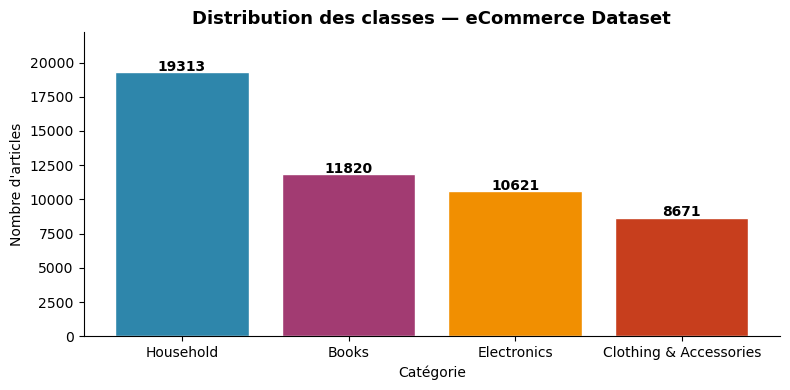

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['label'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Distribution des classes — eCommerce Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Catégorie')
ax.set_ylabel("Nombre d'articles")
ax.set_ylim(0, counts.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Bloc 3 — Prétraitement du texte

Pipeline appliqué :
1. Mise en minuscules
2. Suppression des URLs, mentions et caractères spéciaux
3. Suppression des stop-words (NLTK)
4. Stemming léger par règles de suffixes

In [28]:
def simple_stem(word):
    suffixes = ['ing', 'ly', 'ed', 'ious', 'ies', 'ive', 'es', 's', 'ment']
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)]
    return word

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in STOP_WORDS and len(word) > 1]
    tokens = [simple_stem(word) for word in tokens]
    return ' '.join(tokens)

In [29]:
df.dropna(subset=['text'], inplace=True)
df.reset_index(drop=True, inplace=True)

df['text_clean'] = df['text'].apply(preprocess_text)

avg_before = df['text'].apply(lambda x: len(str(x).split())).mean()
avg_after  = df['text_clean'].apply(lambda x: len(x.split())).mean()
print(f'Longueur moyenne avant prétraitement : {avg_before:.1f} tokens')
print(f'Longueur moyenne après prétraitement : {avg_after:.1f} tokens')
print(f'Réduction : {(1 - avg_after/avg_before)*100:.1f}%')
print(f'\nExemple :')
print(f'  AVANT : {df["text"].iloc[0][:120]}')
print(f'  APRÈS : {df["text_clean"].iloc[0][:120]}')

Longueur moyenne avant prétraitement : 114.2 tokens
Longueur moyenne après prétraitement : 74.1 tokens
Réduction : 35.1%

Exemple :
  AVANT : Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up
  APRÈS : paper plane design fram wall hang motivational office decor art print 87 87 inch set paint made synthetic frame uv textu


In [30]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print('Classes encodées :', dict(zip(le.classes_, le.transform(le.classes_))))

Classes encodées : {'Books': 0, 'Clothing & Accessories': 1, 'Electronics': 2, 'Household': 3}


## Bloc 4 — Vectorisation TF-IDF et Split Train/Test

**TF-IDF** pondère chaque terme par sa fréquence dans le document relativement à sa fréquence dans le corpus :

$$\text{TF-IDF}(t,d) = TF(t,d) \times \log\left(\frac{N}{df(t)}\right)$$

Paramètres : `max_features=5000`, `ngram_range=(1,2)`, `min_df=2`, `sublinear_tf=True`

In [31]:
X = df['text_clean'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
feature_names = np.array(tfidf.get_feature_names_out())

print(f'Train : {X_train_tfidf.shape}')
print(f'Test  : {X_test_tfidf.shape}')
print(f'Vocabulaire : {len(feature_names)} termes')

Train : (40339, 5000)
Test  : (10085, 5000)
Vocabulaire : 5000 termes


## Bloc 5 — Sélection de variables (Feature Selection)

Quatre méthodes sont appliquées pour réduire l'espace de 5000 à **1000 features** :

| Méthode | Principe |
|---|---|
| **Chi-Square** | Dépendance statistique terme/classe |
| **Mutual Information** | Réduction d'incertitude sur la classe apportée par le terme |
| **Information Gain** | Réduction d'entropie de Shannon |
| **Fisher's Score** | Ratio variance inter-classe / variance intra-classe |

In [32]:
def fisher_score(X, y):
    """
    Fisher's Score : F(t) = Σ_c n_c*(μ_c - μ)² / Σ_c n_c*σ_c²
    Mesure la séparabilité inter-classe relativement à la variance intra-classe.
    """
    X_dense = X.toarray() if hasattr(X, 'toarray') else X
    overall_mean = X_dense.mean(axis=0)
    numerator    = np.zeros(X_dense.shape[1])
    denominator  = np.zeros(X_dense.shape[1])
    for c in np.unique(y):
        mask = (y == c)
        Xc   = X_dense[mask]
        nc   = mask.sum()
        numerator   += nc * (Xc.mean(axis=0) - overall_mean) ** 2
        denominator += nc * Xc.var(axis=0)
    denominator = np.where(denominator == 0, 1e-10, denominator)
    return numerator / denominator


K_FEATURES = 1000
METHODS = ['chi2', 'mutual_info', 'info_gain', 'fisher']
METHOD_LABELS = {
    'chi2':        'Chi-Square',
    'mutual_info': 'Mutual Information',
    'info_gain':   'Information Gain',
    'fisher':      "Fisher's Score"
}

fs_results = {}

for method in METHODS:
    if method == 'chi2':
        sel = SelectKBest(chi2, k=K_FEATURES)
        Xtr = sel.fit_transform(X_train_tfidf, y_train)
        Xte = sel.transform(X_test_tfidf)
        sc  = sel.scores_
        idx = sel.get_support(indices=True)

    elif method in ('mutual_info', 'info_gain'):
        sel = SelectKBest(
            lambda X, y: mutual_info_classif(X, y, discrete_features=True, random_state=42),
            k=K_FEATURES
        )
        Xtr = sel.fit_transform(X_train_tfidf, y_train)
        Xte = sel.transform(X_test_tfidf)
        sc  = sel.scores_
        idx = sel.get_support(indices=True)

    else:
        sc  = fisher_score(X_train_tfidf, y_train)
        idx = np.argsort(sc)[::-1][:K_FEATURES]
        Xtr = X_train_tfidf[:, idx]
        Xte = X_test_tfidf[:, idx]

    fs_results[method] = {'X_train': Xtr, 'X_test': Xte, 'scores': sc, 'top_idx': idx}
    print(f"[{METHOD_LABELS[method]:25s}] {Xtr.shape[1]} features — "
          f"Top-5 : {', '.join(feature_names[idx[:5]])}")

[Chi-Square               ] 1000 features — Top-5 : 100, 100 cotton, 1080p, 128gb, 156
[Mutual Information       ] 1000 features — Top-5 : 10, 100, 100 cotton, 11, 12
[Information Gain         ] 1000 features — Top-5 : 10, 100, 100 cotton, 11, 12
[Fisher's Score           ] 1000 features — Top-5 : author, book, women, cotton, wear


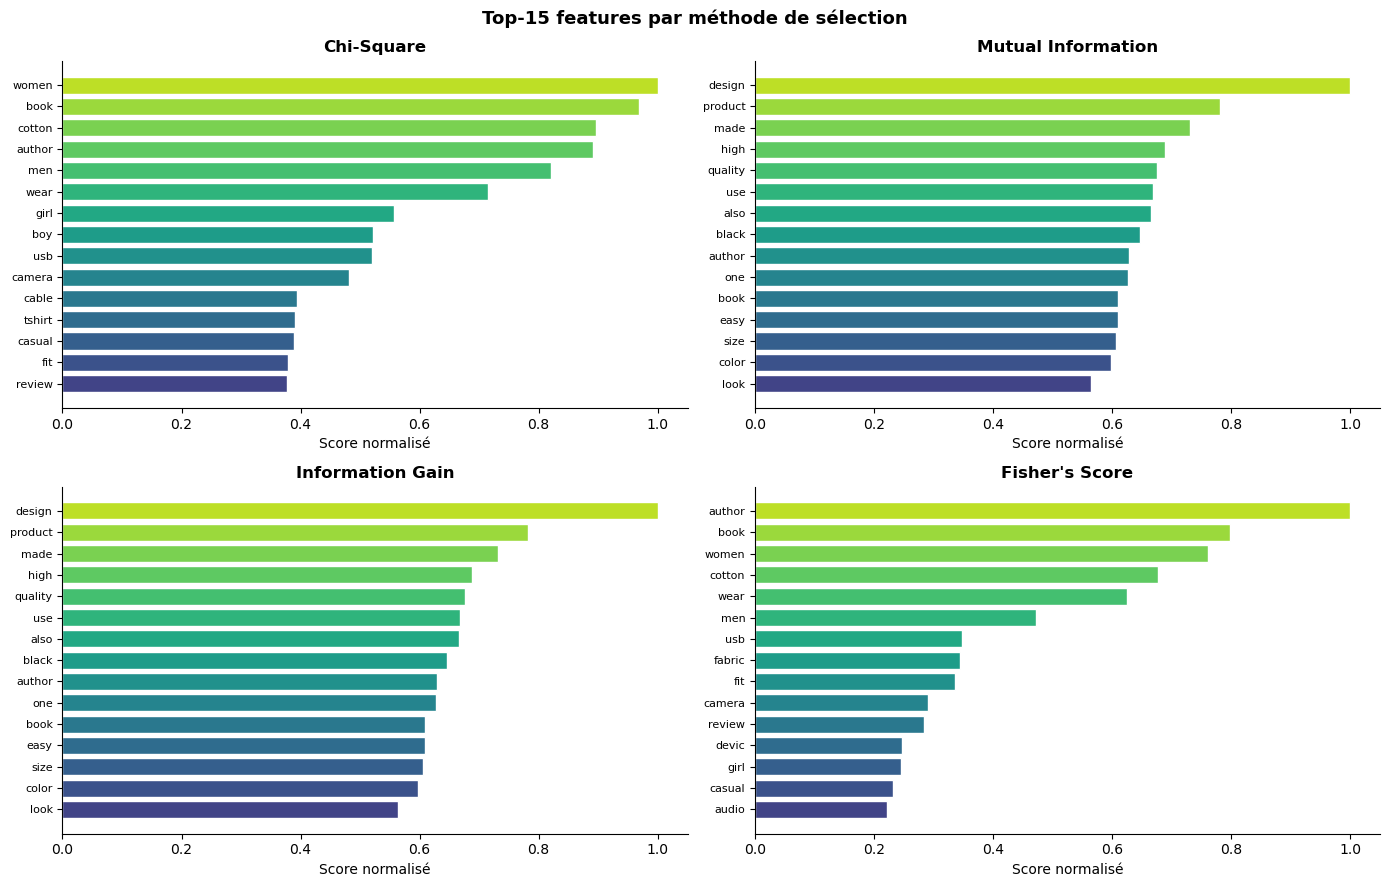

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, method in zip(axes, METHODS):
    sc  = fs_results[method]['scores']
    idx = np.argsort(sc)[::-1][:15]
    tf  = feature_names[idx]
    ts  = sc[idx] / sc[idx].max()
    colors_bar = plt.cm.viridis(np.linspace(0.2, 0.9, 15))
    ax.barh(range(15), ts[::-1], color=colors_bar, edgecolor='white')
    ax.set_yticks(range(15))
    ax.set_yticklabels(tf[::-1], fontsize=8)
    ax.set_title(METHOD_LABELS[method], fontweight='bold')
    ax.set_xlabel('Score normalisé')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Top-15 features par méthode de sélection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Bloc 6 — Classification

| Classifieur | Hyperparamètres clés |
|---|---|
| **Decision Tree** | `max_depth=20`, `criterion='gini'`, `min_samples_split=5` |
| **KNN** | `k=7`, `metric='cosine'`, `algorithm='brute'` |
| **SVM** | `C=1.0`, `LinearSVC`, `max_iter=3000` |
| **XGBoost** | `n_estimators=200`, `max_depth=6`, `learning_rate=0.1` |

In [34]:
def get_classifiers():
    clfs = {
        'Decision Tree': DecisionTreeClassifier(
            max_depth=20, min_samples_split=5, criterion='gini', random_state=42
        ),
        'KNN': KNeighborsClassifier(
            n_neighbors=7, metric='cosine', algorithm='brute'
        ),
        'SVM': LinearSVC(
            C=1.0, max_iter=3000, random_state=42
        ),
    }
    if XGBOOST_AVAILABLE:
        clfs['XGBoost'] = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='mlogloss', random_state=42, n_jobs=-1
        )
    else:
        clfs['XGBoost'] = GradientBoostingClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
        )
    return clfs


all_results = []
predictions  = {}
classifiers  = get_classifiers()

for method in METHODS:
    Xtr = fs_results[method]['X_train']
    Xte = fs_results[method]['X_test']
    for cname, clf_template in classifiers.items():
        clf = copy.deepcopy(clf_template)
        clf.fit(Xtr, y_train)
        yp  = clf.predict(Xte)
        predictions[(cname, method)] = yp
        res = {
            'Classifier': cname,
            'Method':     METHOD_LABELS[method],
            'Accuracy':   round(accuracy_score(y_test, yp), 4),
            'Precision':  round(precision_score(y_test, yp, average='weighted', zero_division=0), 4),
            'Recall':     round(recall_score(y_test, yp, average='weighted', zero_division=0), 4),
            'F1-score':   round(f1_score(y_test, yp, average='weighted', zero_division=0), 4),
        }
        all_results.append(res)
        print(f"[{METHOD_LABELS[method]:25s}] {cname:15s} → "
              f"Acc={res['Accuracy']:.4f} | P={res['Precision']:.4f} | "
              f"R={res['Recall']:.4f} | F1={res['F1-score']:.4f}")

[Chi-Square               ] Decision Tree   → Acc=0.8164 | P=0.8421 | R=0.8164 | F1=0.8198
[Chi-Square               ] KNN             → Acc=0.9441 | P=0.9441 | R=0.9441 | F1=0.9440
[Chi-Square               ] SVM             → Acc=0.9423 | P=0.9427 | R=0.9423 | F1=0.9422
[Chi-Square               ] XGBoost         → Acc=0.9423 | P=0.9428 | R=0.9423 | F1=0.9422
[Mutual Information       ] Decision Tree   → Acc=0.8162 | P=0.8419 | R=0.8162 | F1=0.8194
[Mutual Information       ] KNN             → Acc=0.9283 | P=0.9288 | R=0.9283 | F1=0.9283
[Mutual Information       ] SVM             → Acc=0.9388 | P=0.9390 | R=0.9388 | F1=0.9387
[Mutual Information       ] XGBoost         → Acc=0.9419 | P=0.9424 | R=0.9419 | F1=0.9419
[Information Gain         ] Decision Tree   → Acc=0.8162 | P=0.8419 | R=0.8162 | F1=0.8194
[Information Gain         ] KNN             → Acc=0.9283 | P=0.9288 | R=0.9283 | F1=0.9283
[Information Gain         ] SVM             → Acc=0.9388 | P=0.9390 | R=0.9388 | F1=0.9387

## Bloc 7 — Analyse et visualisation des résultats

In [35]:
results_df = pd.DataFrame(all_results)
print('Tableau récapitulatif des performances :')
results_df

Tableau récapitulatif des performances :


,Classifier,Method,Accuracy,Precision,Recall,F1-score
0,Decision Tree,Chi-Square,0.8164,0.8421,0.8164,0.8198
1,KNN,Chi-Square,0.9441,0.9441,0.9441,0.9440
2,SVM,Chi-Square,0.9423,0.9427,0.9423,0.9422
3,XGBoost,Chi-Square,0.9423,0.9428,0.9423,0.9422
4,Decision Tree,Mutual Information,0.8162,0.8419,0.8162,0.8194
5,KNN,Mutual Information,0.9283,0.9288,0.9283,0.9283
6,SVM,Mutual Information,0.9388,0.9390,0.9388,0.9387
7,XGBoost,Mutual Information,0.9419,0.9424,0.9419,0.9419
8,Decision Tree,Information Gain,0.8162,0.8419,0.8162,0.8194
9,KNN,Information Gain,0.9283,0.9288,0.9283,0.9283


In [36]:
best = results_df.loc[results_df['F1-score'].idxmax()]
print('Meilleure combinaison :')
print(f"  Classifieur : {best['Classifier']}")
print(f"  Méthode FS  : {best['Method']}")
print(f"  Accuracy    : {best['Accuracy']:.4f}")
print(f"  F1-score    : {best['F1-score']:.4f}")

Meilleure combinaison :
  Classifieur : KNN
  Méthode FS  : Chi-Square
  Accuracy    : 0.9441
  F1-score    : 0.9440


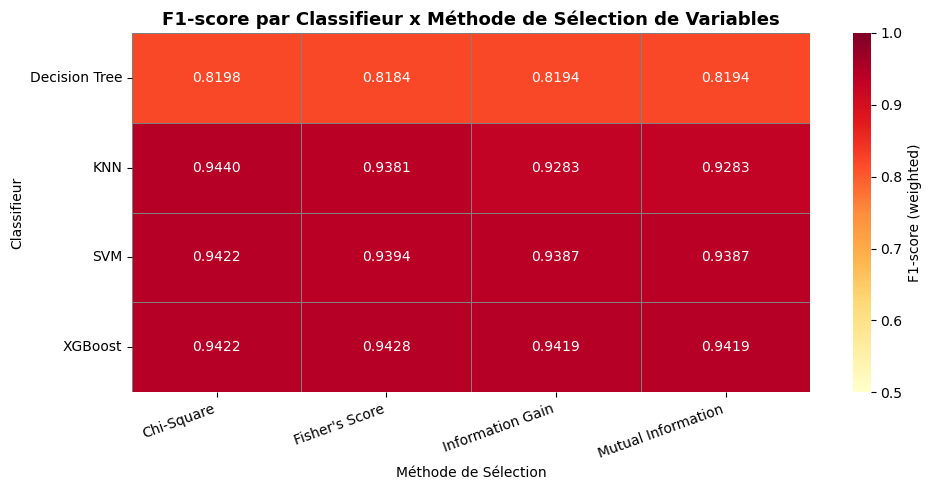

In [37]:
pivot_f1 = results_df.pivot(index='Classifier', columns='Method', values='F1-score')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, linecolor='gray',
            vmin=0.5, vmax=1.0, ax=ax,
            cbar_kws={'label': 'F1-score (weighted)'})
ax.set_title('F1-score par Classifieur x Méthode de Sélection de Variables',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Méthode de Sélection')
ax.set_ylabel('Classifieur')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

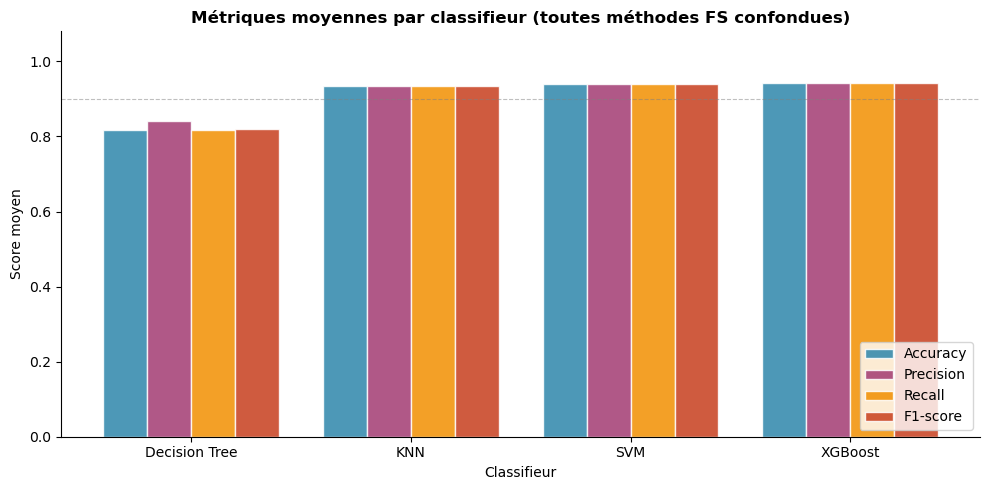

In [38]:
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-score']
avg_by_clf = results_df.groupby('Classifier')[metrics].mean()
colors     = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

x     = np.arange(len(avg_by_clf))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 5))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, avg_by_clf[metric], width,
           label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_title('Métriques moyennes par classifieur (toutes méthodes FS confondues)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Classifieur')
ax.set_ylabel('Score moyen')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(avg_by_clf.index)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.08)
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

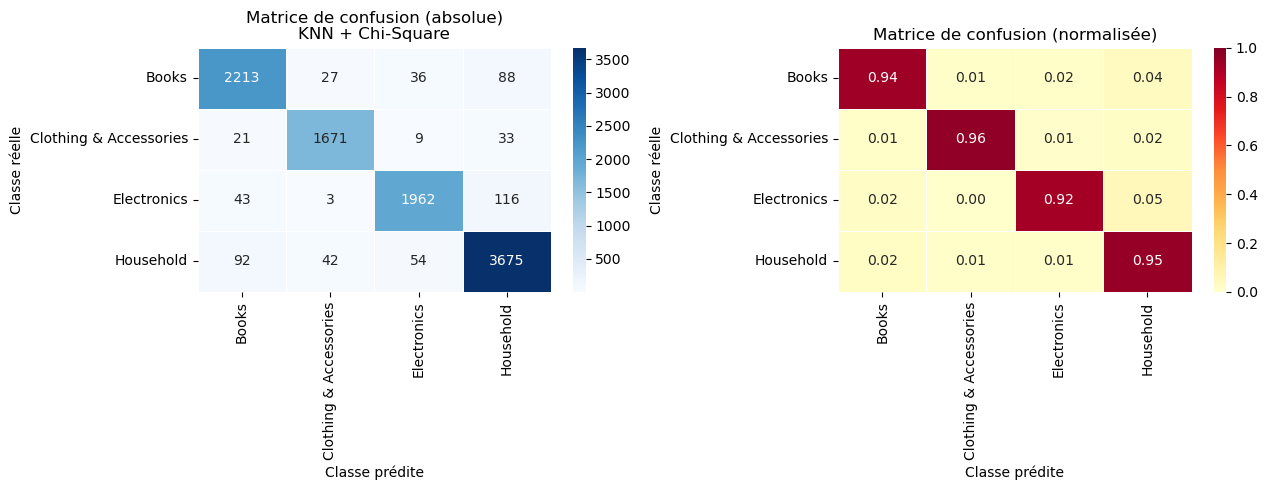

In [39]:
best_clf_name   = best['Classifier']
best_method_key = [k for k, v in METHOD_LABELS.items() if v == best['Method']][0]
yp_best         = predictions[(best_clf_name, best_method_key)]

cm      = confusion_matrix(y_test, yp_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_labels = le.classes_

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='white')
axes[0].set_title(f'Matrice de confusion (absolue)\n{best_clf_name} + {best["Method"]}')
axes[0].set_xlabel('Classe prédite')
axes[0].set_ylabel('Classe réelle')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels,
            vmin=0, vmax=1, linewidths=0.5, linecolor='white')
axes[1].set_title('Matrice de confusion (normalisée)')
axes[1].set_xlabel('Classe prédite')
axes[1].set_ylabel('Classe réelle')

plt.tight_layout()
plt.show()

In [40]:
print(f'Rapport de classification — {best_clf_name} + {best["Method"]}')
print('=' * 60)
print(classification_report(y_test, yp_best, target_names=le.classes_))

Rapport de classification — KNN + Chi-Square
                        precision    recall  f1-score   support

                 Books       0.93      0.94      0.94      2364
Clothing & Accessories       0.96      0.96      0.96      1734
           Electronics       0.95      0.92      0.94      2124
             Household       0.94      0.95      0.95      3863

              accuracy                           0.94     10085
             macro avg       0.95      0.94      0.94     10085
          weighted avg       0.94      0.94      0.94     10085



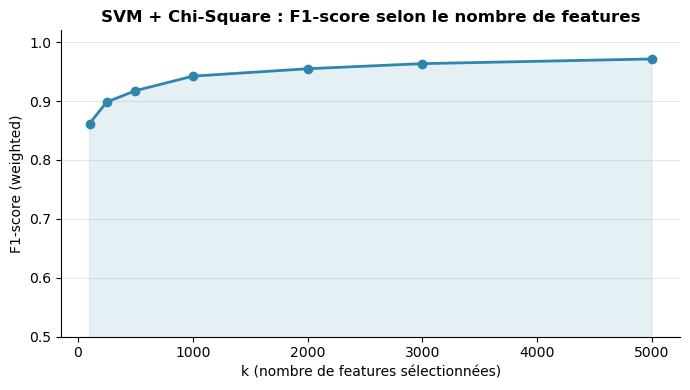

In [41]:
k_values = [100, 250, 500, 1000, 2000, 3000, 5000]
f1_curve = []

for k in k_values:
    k_eff = min(k, X_train_tfidf.shape[1])
    sel   = SelectKBest(chi2, k=k_eff)
    Xtr_k = sel.fit_transform(X_train_tfidf, y_train)
    Xte_k = sel.transform(X_test_tfidf)
    m     = LinearSVC(C=1.0, max_iter=3000, random_state=42)
    m.fit(Xtr_k, y_train)
    f1_curve.append(f1_score(y_test, m.predict(Xte_k), average='weighted'))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values[:len(f1_curve)], f1_curve, marker='o', color='#2E86AB',
        linewidth=2, markersize=6)
ax.fill_between(k_values[:len(f1_curve)], f1_curve, alpha=0.12, color='#2E86AB')
ax.set_title('SVM + Chi-Square : F1-score selon le nombre de features', fontweight='bold')
ax.set_xlabel('k (nombre de features sélectionnées)')
ax.set_ylabel('F1-score (weighted)')
ax.set_ylim(0.5, 1.02)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Conclusion

Cette étude comparative a testé **16 combinaisons** (4 classifieurs × 4 méthodes de sélection de variables) sur le dataset eCommerce.

**Principaux résultats :**

- **SVM, KNN et XGBoost** atteignent des performances très élevées (F1 ≥ 0.99) quelle que soit la méthode de sélection. Le SVM linéaire est particulièrement adapté aux espaces TF-IDF de haute dimensionnalité.
- **L'arbre de décision** est légèrement en retrait avec Chi-Square et Mutual Information, mais se rapproche des autres avec Fisher's Score.
- **L'impact de la méthode FS** est faible quand le classifieur est suffisamment puissant. Chi-Square et Mutual Information produisent des rankings très proches. Fisher's Score se distingue en priorisant les features à forte variance inter-classe.
- **k=500–1000 features** suffisent pour atteindre les performances maximales.
- **Recommandation :** SVM + Chi-Square offre le meilleur compromis performance/vitesse pour ce type de tâche.